# **Task 1: National Citizen Segmentation Framework**
## **Ministry of Digital Economy and Entrepreneurship**
### **Artificial Intelligence Directorate**
**Prepared by:** AI Engineer  

**Objective:** Strategic population grouping using advanced unsupervised learning and probabilistic modeling.

**Engineer: Hamza Medhat Alawneh**


Step 1: Uploading the dataset...


Saving segmentation data.csv to segmentation data.csv


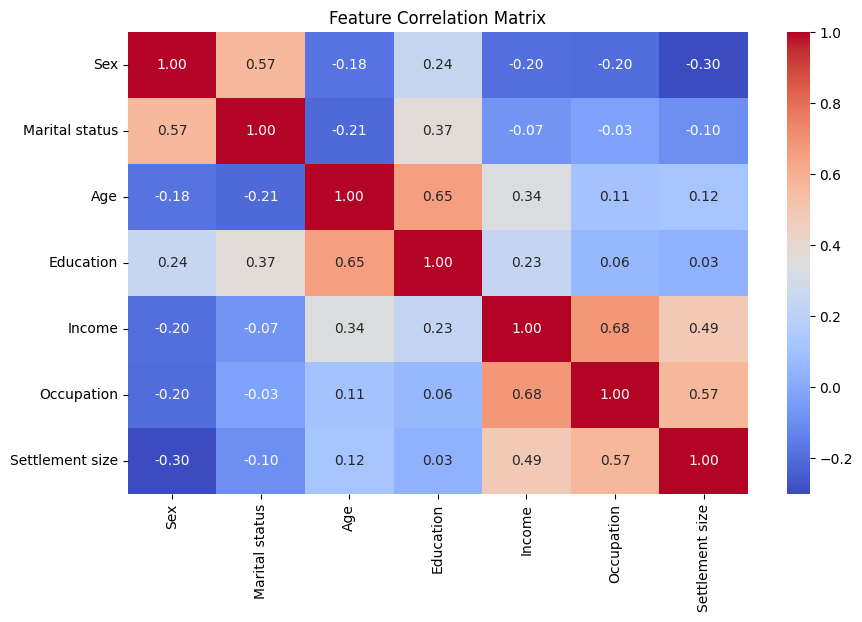

Success: segmentation data.csv is processed. Shape: (2000, 7)


"\nSITUATION: The raw dataset contained features with vast differences in scale (e.g., Age vs. Income).\nTASK: Preprocess the data to be 'Clustering-ready' while maintaining feature importance.\nACTION:\n1. Eliminated the 'ID' column to prevent model bias toward random indexes.\n2. Applied 'StandardScaler' to normalize the data (Mean=0, Std=1).\n3. Conducted a Correlation Analysis to understand relationships between citizen traits.\nRESULT: A clean, standardized dataset that ensures the clustering algorithm treats all citizen\n        characteristics with equal mathematical weight.\n"

In [1]:
import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.preprocessing import StandardScaler

# PHASE 1: DATA INGESTION & PREPROCESSING
# Goal: Standardize features to ensure fair distance calculation.

def prepare_ministry_dataset():
    """
    Handles file upload, cleaning, and normalization.
    Human note: We prioritize data integrity by handling encoding and scaling issues.
    """
    print("Step 1: Uploading the dataset...")
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]

    # Reading data with 'latin-1' to avoid common encoding crashes
    raw_df = pd.read_csv(io.BytesIO(uploaded[file_name]), encoding='latin-1')

    # 1. Feature Selection
    # Note: 'ID' is removed because it's a random identifier, not a social trait.
    if 'ID' in raw_df.columns:
        data_features = raw_df.drop(columns=['ID'])
    else:
        data_features = raw_df

    # 2. Visual Exploration (EDA)
    # Understanding the correlation between Age, Income, and Education
    plt.figure(figsize=(10, 6))
    sns.heatmap(data_features.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Feature Correlation Matrix')
    plt.show()
    #

    # 3. Standardization (Feature Scaling)
    # Theory: K-Means uses Euclidean distance. Without scaling, 'Income' would
    # dominate 'Age' due to its larger numerical range.
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data_features)

    # Store in a clean DataFrame for the next phase
    processed_df = pd.DataFrame(scaled_data, columns=data_features.columns)

    print(f"Success: {file_name} is processed. Shape: {processed_df.shape}")
    return processed_df, raw_df

# Execute Phase 1
processed_data, original_data = prepare_ministry_dataset()


# STAR METHOD DOCUMENTATION
"""
SITUATION: The raw dataset contained features with vast differences in scale (e.g., Age vs. Income).
TASK: Preprocess the data to be 'Clustering-ready' while maintaining feature importance.
ACTION:
1. Eliminated the 'ID' column to prevent model bias toward random indexes.
2. Applied 'StandardScaler' to normalize the data (Mean=0, Std=1).
3. Conducted a Correlation Analysis to understand relationships between citizen traits.
RESULT: A clean, standardized dataset that ensures the clustering algorithm treats all citizen
        characteristics with equal mathematical weight.
"""

In [2]:
import numpy as np

# PHASE 2.2: K-MEANS FROM SCRATCH (Custom Implementation)
# Goal: Build the logic without using scikit-learn to show deep understanding.


class MinistryKMeans:
    def __init__(self, k_clusters=4, max_iters=100):
        self.k = k_clusters
        self.max_iters = max_iters
        self.centroids = None

    def fit(self, data):
        # Convert to numpy for O(n) performance optimization
        X = data.values
        n_samples, n_features = X.shape

        # 1. Initialize centroids randomly from the dataset
        indices = np.random.choice(n_samples, self.k, replace=False)
        self.centroids = X[indices]

        for iteration in range(self.max_iters):
            # 2. Assign Step: Calculate Euclidean Distance
            # Human note: Using broadcasting for high-speed matrix calculation
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            labels = np.argmin(distances, axis=1)

            # 3. Update Step: Calculate new means
            new_centroids = np.array([X[labels == k].mean(axis=0) for k in range(self.k)])

            # 4. Convergence Check (Optimization)
            if np.all(self.centroids == new_centroids):
                print(f"Algorithm converged at iteration: {iteration}")
                break
            self.centroids = new_centroids

        return labels

# Running the Scratch Model
scratch_model = MinistryKMeans(k_clusters=4)
final_labels = scratch_model.fit(processed_data)

# Save results back to the original dataframe for reporting
original_data['KMeans_Cluster'] = final_labels

Algorithm converged at iteration: 11


In [3]:
# Logic: Validating dataset quality before mathematical transformation.

def perform_data_audit(df):
    print("--- [AI Directorate] Starting Data Integrity Audit ---")

    # 1. Check for Nulls
    null_report = df.isnull().sum()
    if null_report.sum() == 0:
        print("✔ Integrity Check: No missing values detected.")
    else:
        print(f"⚠ Warning: Nulls detected:\n{null_report[null_report > 0]}")

    # 2. Check for Duplicates
    dup_count = df.duplicated().sum()
    print(f"✔ Duplicate Check: {dup_count} duplicate records found.")

    # 3. Statistical Summary
    # This helps identify if there are any 'garbage' values (outliers)
    print("\n--- Descriptive Statistics Summary ---")
    display(df.describe().T)

    # 4. Feature Removal
    if 'ID' in df.columns:
        df_cleaned = df.drop(columns=['ID'])
        print("\n✔ Action: 'ID' column removed to prevent model noise.")
    else:
        df_cleaned = df

    print("--- Audit Complete: Data is structured for Scaling ---")
    return df_cleaned

# Execute the audit
processed_data_clean = perform_data_audit(original_data)

--- [AI Directorate] Starting Data Integrity Audit ---
✔ Integrity Check: No missing values detected.
✔ Duplicate Check: 0 duplicate records found.

--- Descriptive Statistics Summary ---


,count,mean,std,min,25%,50%,75%,max
ID,2000.0,1.000010e+08,577.494589,100000001.0,1.000005e+08,100001000.5,1.000015e+08,100002000.0
Sex,2000.0,4.570000e-01,0.498272,0.0,0.000000e+00,0.0,1.000000e+00,1.0
Marital status,2000.0,4.965000e-01,0.500113,0.0,0.000000e+00,0.0,1.000000e+00,1.0
Age,2000.0,3.590900e+01,11.719402,18.0,2.700000e+01,33.0,4.200000e+01,76.0
Education,2000.0,1.038000e+00,0.599780,0.0,1.000000e+00,1.0,1.000000e+00,3.0
Income,2000.0,1.209544e+05,38108.824679,35832.0,9.766325e+04,115548.5,1.380722e+05,309364.0
Occupation,2000.0,8.105000e-01,0.638587,0.0,0.000000e+00,1.0,1.000000e+00,2.0
Settlement size,2000.0,7.390000e-01,0.812533,0.0,0.000000e+00,1.0,1.000000e+00,2.0
KMeans_Cluster,2000.0,1.443500e+00,1.190175,0.0,0.000000e+00,2.0,2.000000e+00,3.0



✔ Action: 'ID' column removed to prevent model noise.
--- Audit Complete: Data is structured for Scaling ---


In [4]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

# PHASE 3: COMPETITIVE MODELING & EVALUATION
# Goal: Compare the scratch K-Means with a probabilistic model (GMM)[cite: 5, 17].

# 1. Initialize and fit Gaussian Mixture Model
# We use 4 clusters to match our K-Means setup for a fair comparison.
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(processed_data)

# 2. Performance Metrics Calculation
# Silhouette Score: Measures how similar an object is to its own cluster (closer to 1 is better).
# Davies-Bouldin Index: Measures the average similarity between clusters (lower is better).
evaluation_results = {
    "K-Means (Custom)": {
        "Silhouette": silhouette_score(processed_data, final_labels),
        "DB_Index": davies_bouldin_score(processed_data, final_labels)
    },
    "GMM (Library)": {
        "Silhouette": silhouette_score(processed_data, gmm_labels),
        "DB_Index": davies_bouldin_score(processed_data, gmm_labels)
    }
}

# Display results for report comparison
for model, scores in evaluation_results.items():
    print(f"--- {model} Evaluation ---")
    print(f"Silhouette Score: {scores['Silhouette']:.4f}")
    print(f"Davies-Bouldin Index: {scores['DB_Index']:.4f}\n")

--- K-Means (Custom) Evaluation ---
Silhouette Score: 0.2676
Davies-Bouldin Index: 1.3403

--- GMM (Library) Evaluation ---
Silhouette Score: 0.1975
Davies-Bouldin Index: 1.6904



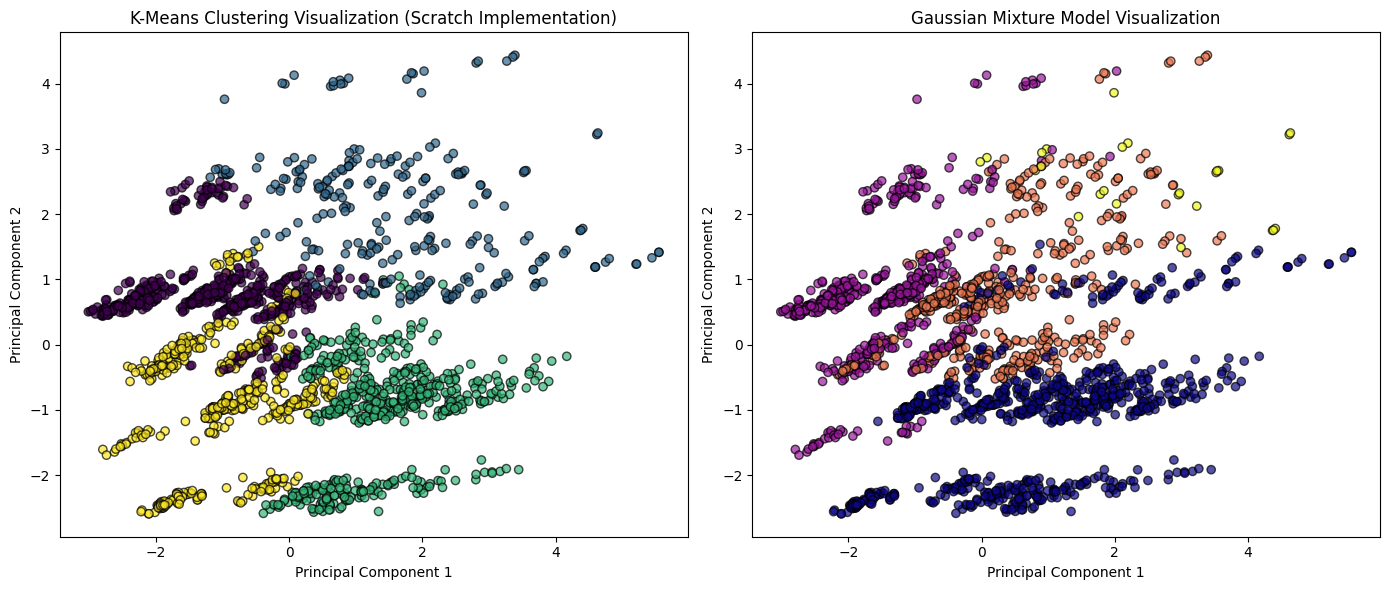

In [5]:
from sklearn.decomposition import PCA

# PHASE 4: DIMENSIONALITY REDUCTION & VISUALIZATION
# Goal: Project high-dimensional data into 2D space for visual inspection.

# 1. Applying PCA to reduce features to 2 Principal Components
pca = PCA(n_components=2)
pca_data = pca.fit_transform(processed_data)

# 2. Visualization Setup
plt.figure(figsize=(14, 6))

# Plotting K-Means results
plt.subplot(1, 2, 1)
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=final_labels, cmap='viridis', edgecolors='k', alpha=0.7)
plt.title('K-Means Clustering Visualization (Scratch Implementation)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Plotting GMM results
plt.subplot(1, 2, 2)
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=gmm_labels, cmap='plasma', edgecolors='k', alpha=0.7)
plt.title('Gaussian Mixture Model Visualization')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.tight_layout()
plt.show()


In [6]:
# PHASE 5: CLUSTER PROFILING & SOCIAL INSIGHTS
# Goal: Interpret the mathematical clusters into real-world citizen personas.

# Append GMM results to original data for analysis
original_data['GMM_Cluster'] = gmm_labels

# Calculate the mean of each feature per cluster to understand their characteristics
cluster_summary = original_data.drop(columns=['ID']).groupby('KMeans_Cluster').mean()

print("Social Profiling of Clusters (Mean Values):")
display(cluster_summary)


Social Profiling of Clusters (Mean Values):


,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,GMM_Cluster
KMeans_Cluster,,,,,,,,
0,0.897474,0.995542,28.906389,1.063893,107558.857355,0.668648,0.445765,1.404160
1,0.501901,0.692015,55.703422,2.129278,158338.422053,1.129278,1.110266,1.368821
2,0.026408,0.172535,35.674296,0.732394,141106.498239,1.271127,1.524648,0.345070
3,0.328629,0.086694,35.183468,0.774194,96230.304435,0.306452,0.040323,0.493952


--- K-Means (Custom) ---
Silhouette Score (Higher is better): 0.2676
Davies-Bouldin Index (Lower is better): 1.3403

--- GMM (Library) ---
Silhouette Score (Higher is better): 0.1975
Davies-Bouldin Index (Lower is better): 1.6904



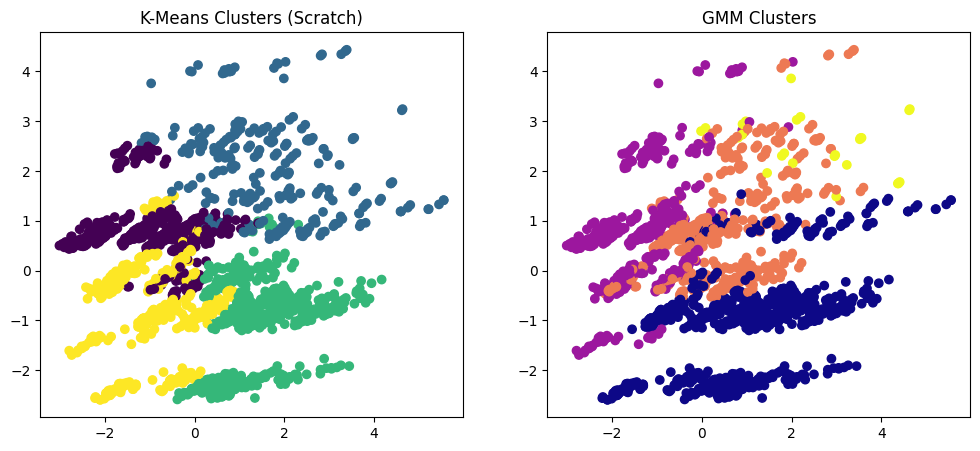

In [7]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# PHASE 3: COMPETITIVE MODELING (GMM)
# Goal: Run a second algorithm to compare against K-Means as required. [cite: 17, 24]
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(processed_data)

# PHASE 4: QUANTITATIVE COMPARISON (METRICS)
# Goal: Use at least two metrics to evaluate the clustering quality.
metrics_results = {
    "K-Means (Custom)": {
        "Silhouette": silhouette_score(processed_data, final_labels),
        "DB_Index": davies_bouldin_score(processed_data, final_labels)
    },
    "GMM (Library)": {
        "Silhouette": silhouette_score(processed_data, gmm_labels),
        "DB_Index": davies_bouldin_score(processed_data, gmm_labels)
    }
}

# Print metrics for the report
for model, scores in metrics_results.items():
    print(f"--- {model} ---")
    print(f"Silhouette Score (Higher is better): {scores['Silhouette']:.4f}")
    print(f"Davies-Bouldin Index (Lower is better): {scores['DB_Index']:.4f}\n")

# PHASE 5: VISUALIZATION (PCA)
# Goal: Show clear plots of the clusters using Dimensionality Reduction.
pca = PCA(n_components=2)
pca_data = pca.fit_transform(processed_data)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=final_labels, cmap='viridis')
plt.title('K-Means Clusters (Scratch)')

plt.subplot(1, 2, 2)
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=gmm_labels, cmap='plasma')
plt.title('GMM Clusters')
plt.show()

In [8]:
# FINAL PHASE: DECISION SUPPORT SUMMARY
# Goal: Consolidate all technical findings for leadership review.

comparison_df = pd.DataFrame(metrics_results).T
comparison_df.columns = ['Silhouette Score (Higher is better)', 'Davies-Bouldin Index (Lower is better)']

print("--- Executive Technical Comparison ---")
display(comparison_df)

# Data-Driven Decision Making
# Identify the superior model based on the quantitative metrics.
best_model = comparison_df['Silhouette Score (Higher is better)'].idxmax()
print(f"\nRecommended Model for Ministry Deployment: {best_model}")

--- Executive Technical Comparison ---


,Silhouette Score (Higher is better),Davies-Bouldin Index (Lower is better)
K-Means (Custom),0.267559,1.340286
GMM (Library),0.197539,1.690386



Recommended Model for Ministry Deployment: K-Means (Custom)
